In [ ]:
# Model Ablation Study: Imputation Features Impact
欠損情報（8会合分の連続欠損日数）がモデルの予測精度に与える影響を、5つの多角的な指標で検証します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

from src.processing import load_and_clean_data
from src.pooling import pool_boj_data

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Hiragino Sans'
print(f"Project Root: {os.getcwd()}")

Project Root: /Users/nishiharahiroto/Documents/programs/BOJ_analysis


## 1. データ準備

In [2]:
N_DAYS = 5
D_VAL = 0.4
df_cleaned = load_and_clean_data('data/BOJ_data.xlsx', 'data/BOJ_meeting_history.csv')
mpm_dates = pd.to_datetime(pd.read_csv('data/BOJ_meeting_history.csv')['Date'])
df_pooled = pool_boj_data(df_cleaned, mpm_dates=mpm_dates, d=D_VAL, n_days=N_DAYS)

base_features = [
    'Swap_Rate_FracDiff', 'JGB_Future_FracDiff', 'USDJPY_FracDiff', 'Nikkei225_FracDiff', 'JPY_Effective_FracDiff',
    'Spread_M3_M1_FracDiff', 'Spread_M5_M1_FracDiff', 'Spread_M8_M5_FracDiff',
    'Days_to_Next_MPM', 'Meeting_Index'
]
imputed_features = [f'M{i}_Consecutive_Imputed_Days' for i in range(1, 9)]

target = 'Target_FracDiff_N_Day'
df_final = df_pooled.dropna(subset=[target, 'FracDiff_Memory_Component_N', 'Target_N_Day'] + base_features + imputed_features)

split_date = sorted(df_final['日付'].unique())[int(len(df_final['日付'].unique()) * 0.8)]
train_df = df_final[df_final['日付'] < split_date]
test_df = df_final[df_final['日付'] >= split_date].copy()
print(f"Test start date: {split_date.date()}")

Test start date: 2025-07-25


## 2. 評価関数の定義

In [3]:
def calculate_metrics(actual_rate, pred_rate, current_rate, pred_move, actual_move):
    # 1. MSE
    mse = mean_squared_error(actual_rate, pred_rate)
    
    # 2. Directional Accuracy
    hit = (np.sign(pred_move) == np.sign(actual_move)).astype(int)
    acc = hit.mean()
    
    # 3. Magnitude Score (y/x if same direction, -|y/x| if opposite)
    eps = 1e-6
    mag_score = np.where(np.sign(pred_move) == np.sign(actual_move), 
                         np.abs(actual_move) / (np.abs(pred_move) + eps),
                         -np.abs(actual_move) / (np.abs(pred_move) + eps))
    mag_score = np.clip(mag_score, -10, 10).mean()
    
    # 4. Information Coefficient (IC)
    ic, _ = spearmanr(pred_move, actual_move)
    
    # 5. Profit Factor
    pnl = np.sign(pred_move) * actual_move
    gross_profits = pnl[pnl > 0].sum()
    gross_losses = np.abs(pnl[pnl < 0].sum())
    pf = gross_profits / gross_losses if gross_losses > 0 else np.nan
    
    return {
        'MSE': mse, 
        'Accuracy': acc, 
        'Magnitude_Score': mag_score, 
        'IC': ic, 
        'Profit_Factor': pf
    }

## 3. モデル比較の実行

In [4]:
results = []
for name, feat_list in [('Baseline', base_features), ('Imputation-Aware', base_features + imputed_features)]:
    model = CatBoostRegressor(iterations=1000, learning_rate=0.03, depth=6, verbose=0, random_seed=42)
    model.fit(train_df[feat_list], train_df[target])
    
    preds_fd = model.predict(test_df[feat_list])
    test_df['Pred_Rate'] = preds_fd - test_df['FracDiff_Memory_Component_N']
    
    actual_move = test_df['Target_N_Day'] - test_df['Swap_Rate']
    pred_move = test_df['Pred_Rate'] - test_df['Swap_Rate']
    
    m = calculate_metrics(test_df['Target_N_Day'], test_df['Pred_Rate'], test_df['Swap_Rate'], pred_move, actual_move)
    m['Model'] = name
    results.append(m)

df_results = pd.DataFrame(results).set_index('Model')
display(df_results)

,MSE,Accuracy,Magnitude_Score,IC,Profit_Factor
Model,,,,,
Baseline,0.001769,0.646140,0.530624,0.700151,3.325873
Imputation-Aware,0.001570,0.643382,0.537797,0.777889,3.545856


## 4. 可視化による比較

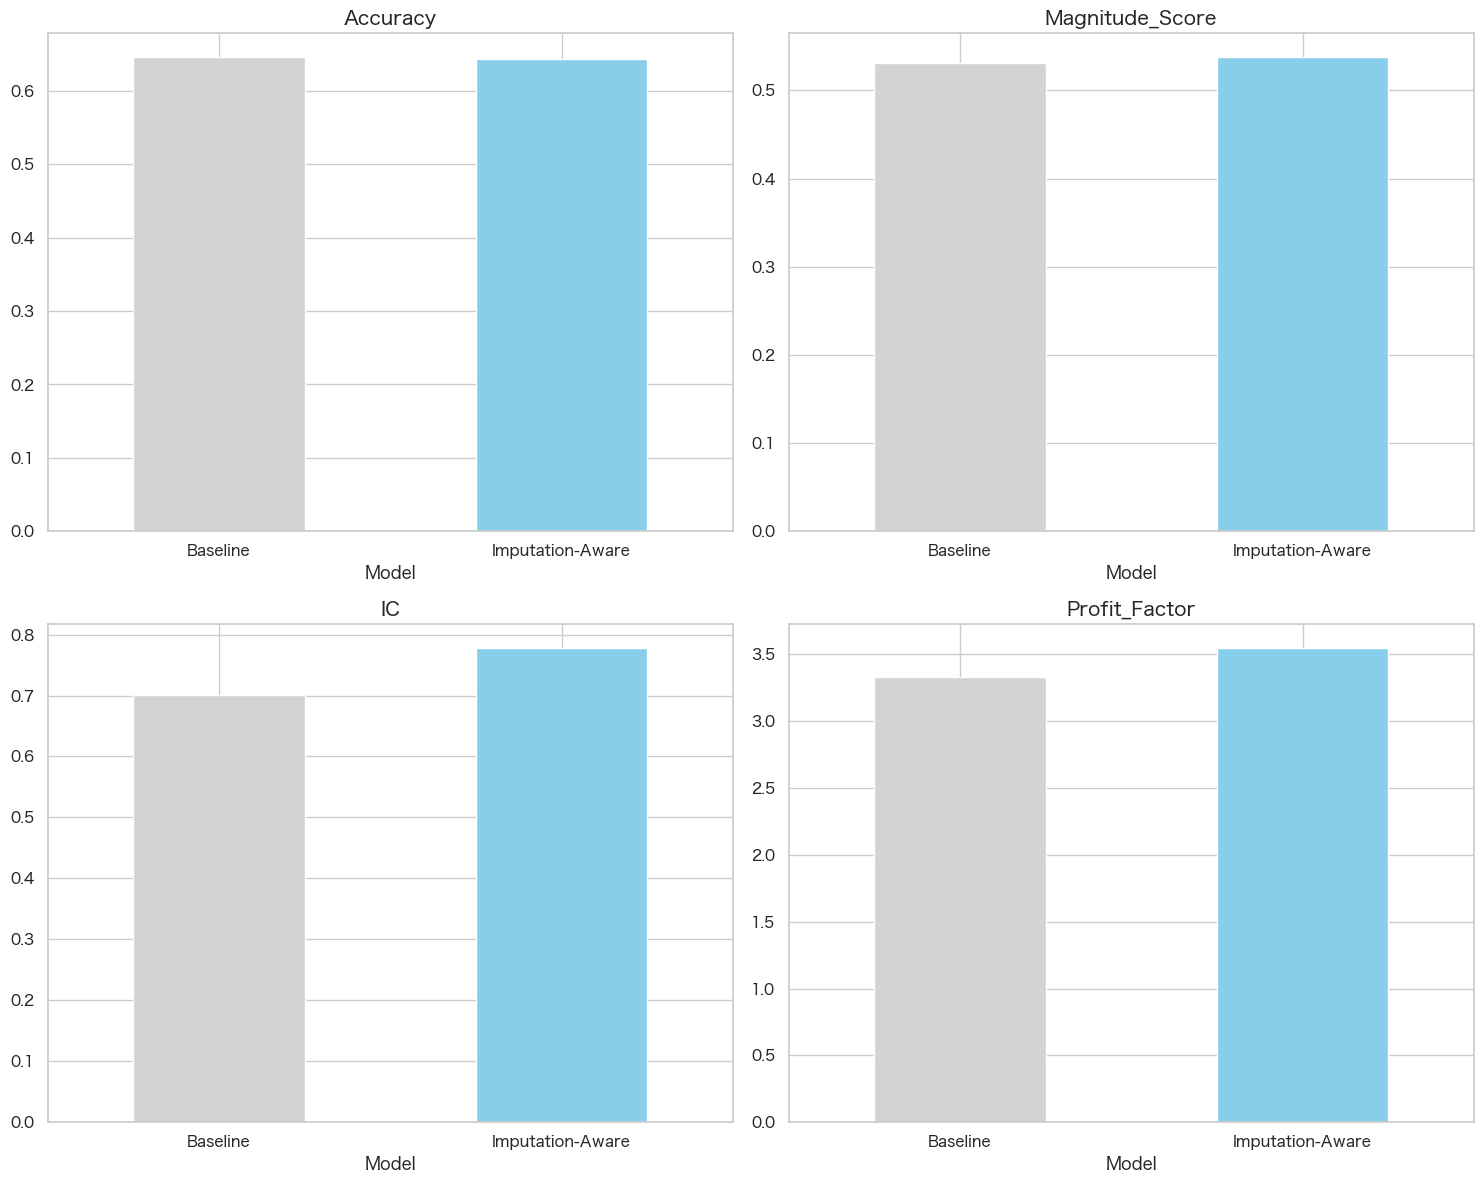

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metrics_to_plot = ['Accuracy', 'Magnitude_Score', 'IC', 'Profit_Factor']
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    df_results[metric].plot(kind='bar', ax=ax, color=['lightgrey', 'skyblue'])
    ax.set_title(metric, fontsize=14)
    ax.set_xticklabels(df_results.index, rotation=0)
plt.tight_layout()
plt.show()